In [70]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import itertools
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [2]:
data = pd.read_excel('dataset.xlsx')
data

,id,sex,q1,q2,q3,q4,q5
0,1,남,0,2,0,70,통학
1,2,여,3,2,0,15,자취
2,3,남,0,0,0,300,통학
3,4,남,0,2,0,160,통학
4,5,남,1,2,0,200,통학
...,...,...,...,...,...,...,...
91,92,여성,2,3,0,90,통학
92,93,남성,7,0,2,60,통학
93,94,여성,3,3,0,90,통학
94,95,여성,1,1,3,15,자취


In [3]:
data['sex'] = data['sex'].replace('남', '1')
data['sex'] = data['sex'].replace('남 ', '1')
data['sex'] = data['sex'].replace('남성', '1')
data['sex'] = data['sex'].replace('여', '2')
data['sex'] = data['sex'].replace('여성', '2')
data['sex'] = data['sex'].astype(int)
data['sex'].unique()

array([1, 2])

In [4]:
data['q5'] = data['q5'].replace('기숙사', '1')
data['q5'] = data['q5'].replace('자취', '2')
data['q5'] = data['q5'].replace('통학', '3')
data['q5'] = data['q5'].astype(int)
data['q5'].unique()

array([3, 2])

In [5]:
print(data)

    id  sex  q1  q2  q3   q4  q5
0    1    1   0   2   0   70   3
1    2    2   3   2   0   15   2
2    3    1   0   0   0  300   3
3    4    1   0   2   0  160   3
4    5    1   1   2   0  200   3
..  ..  ...  ..  ..  ..  ...  ..
91  92    2   2   3   0   90   3
92  93    1   7   0   2   60   3
93  94    2   3   3   0   90   3
94  95    2   1   1   3   15   2
95  96    2   4   3   2   40   3

[96 rows x 7 columns]


In [41]:
male_q1 = data[data['sex'] ==1]['q1']
female_q1 = data[data['sex'] ==2]['q1']

In [7]:
print("남성 그룹 q1 값:", male_q1.describe())
print("여성 그룹 q1 값:", female_q1.describe())

남성 그룹 q1 값: count    53.000000
mean      2.358491
std       1.932459
min       0.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       7.000000
Name: q1, dtype: float64
여성 그룹 q1 값: count    43.000000
mean      2.046512
std       1.731411
min       0.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       7.000000
Name: q1, dtype: float64


In [8]:
model = smf.ols('q1 ~ q2 * sex', data=data).fit()

In [9]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     q1   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     6.027
Date:                Fri, 15 Nov 2024   Prob (F-statistic):           0.000856
Time:                        13:46:10   Log-Likelihood:                -185.76
No. Observations:                  96   AIC:                             379.5
Df Residuals:                      92   BIC:                             389.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4370      0.987      1.456      0.1

In [10]:
data

,id,sex,q1,q2,q3,q4,q5
0,1,1,0,2,0,70,3
1,2,2,3,2,0,15,2
2,3,1,0,0,0,300,3
3,4,1,0,2,0,160,3
4,5,1,1,2,0,200,3
...,...,...,...,...,...,...,...
91,92,2,2,3,0,90,3
92,93,1,7,0,2,60,3
93,94,2,3,3,0,90,3
94,95,2,1,1,3,15,2


In [11]:
df = pd.DataFrame(data)

In [22]:
y = df['q1']
X = df.drop(columns=['q1', 'id', 'sex','q5'])

In [13]:
def get_all_combinations(features):
    combinations = []
    for r in range(1, len(features) + 1):
        combinations.extend(itertools.combinations(features, r))
    return combinations

In [14]:
feature_columns = X.columns
combinations = get_all_combinations(feature_columns)

In [15]:
results = []

In [16]:
for comb in combinations:
    X_comb = sm.add_constant(X[list(comb)])
    model = sm.OLS(y, X_comb).fit()
    results.append({
        'Variables': comb,
        'R-squared': model.rsquared,
        'Adj. R-squared': model.rsquared_adj,
        'AIC': model.aic,
        'BIC': model.bic
    })

In [17]:
results_df = pd.DataFrame(results)

In [20]:
print(results_df.sort_values(by='R-squared', ascending=False))

      Variables  R-squared  Adj. R-squared         AIC         BIC
6  (q2, q3, q4)   0.267746        0.243868  366.820450  377.077843
3      (q2, q3)   0.260191        0.244281  365.805887  373.498932
4      (q2, q4)   0.155590        0.137430  378.501563  386.194608
0         (q2,)   0.155513        0.146529  376.510229  381.638925
5      (q3, q4)   0.140270        0.121781  380.227663  387.920707
1         (q3,)   0.136949        0.127768  378.597691  383.726387
2         (q4,)   0.002918       -0.007689  392.456233  397.584929


In [25]:
X = df[['q2', 'q3']]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

  Variable       VIF
0    const  3.299334
1       q2  1.015707
2       q3  1.015707


In [27]:
X = df[['q2', 'q3']]
y = df['q1']
X = sm.OLS(y,X).fit()
print(model.summary())
params = model.params
print(f"회귀식: y = {params['const']} + {params['q2']}*q2 + {params['q3']}*q3")

                            OLS Regression Results                            
Dep. Variable:                     q1   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     11.21
Date:                Fri, 15 Nov 2024   Prob (F-statistic):           2.44e-06
Time:                        13:59:24   Log-Likelihood:                -179.41
No. Observations:                  96   AIC:                             366.8
Df Residuals:                      92   BIC:                             377.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5458      0.429      1.273      0.2

In [28]:
correlation_matrix = data[['q1', 'q2', 'q3', 'q4', 'q5']].corr()
print(correlation_matrix)

          q1        q2        q3        q4        q5
q1  1.000000  0.394352  0.370067 -0.054018  0.081532
q2  0.394352  1.000000  0.124353 -0.114986 -0.071276
q3  0.370067  0.124353  1.000000 -0.294755 -0.074992
q4 -0.054018 -0.114986 -0.294755  1.000000  0.404898
q5  0.081532 -0.071276 -0.074992  0.404898  1.000000


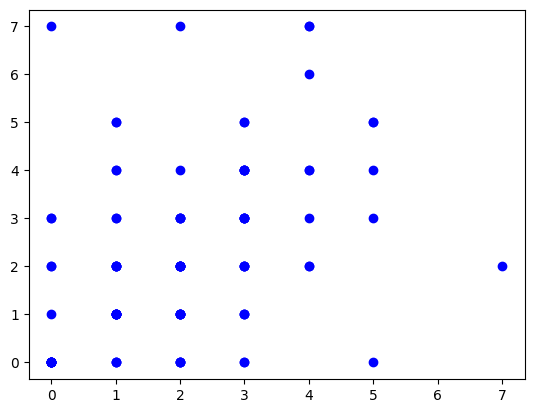

In [39]:
plt.scatter(df['q2'], df['q1'], color='blue')
plt.show()

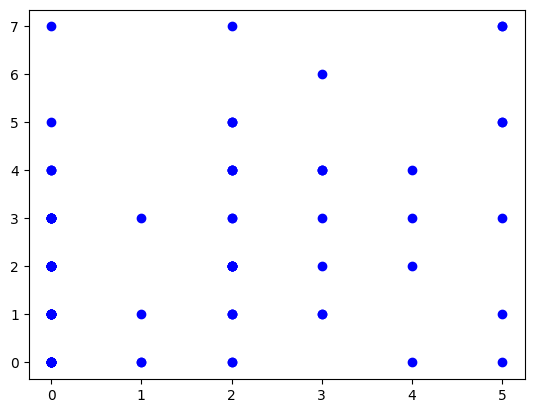

In [44]:
plt.scatter(df['q3'], df['q1'], color='blue')
plt.show()

In [46]:
X = df[['q2', 'q3']]
y = df['q1']

In [62]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

In [64]:
X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(['q2', 'q3']))

In [65]:
model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [67]:
intercept = model.intercept_
coefs = model.coef_

In [69]:
print("회귀식:")
terms = " + ".join([f"({coefs[i]})*{name}" for i, name in enumerate(X_poly_df.columns)])
print(f"y = {intercept} + {terms}")

회귀식:
y = 0.6247114300121384 + (0.724220772619432)*q2 + (0.4763693252597704)*q3 + (-0.06294868510484958)*q2^2 + (0.018507011183169525)*q2 q3 + (-0.03436667386946256)*q3^2


In [71]:
y_pred = model.predict(X_poly)
mse = np.mean((y - y_pred) ** 2)
r2 = model.score(X_poly, y)

In [73]:
print(f"\nMean Squared Error: {mse}")
print(f"R-squared: {r2}")


Mean Squared Error: 2.4493869342511867
R-squared: 0.2706681533372448


In [75]:
X_poly_df = sm.add_constant(X_poly_df)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_poly_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_poly_df.values, i) for i in range(X_poly_df.shape[1])]

In [76]:
print("\nVIF 값:")
print(vif_data)


VIF 값:
  Variable       VIF
0    const  5.901251
1       q2  7.141327
2       q3  9.286496
3     q2^2  7.633463
4    q2 q3  5.201422
5     q3^2  9.418168
